# Trajectory Density Difference

Compares where vases are *positioned* in UMAP space at the start of a round (generation 1, the two seed vases) against where the round's selection actually *ends up* by generation 5, using the same XY-based UMAP embedding as `flow_mapping/trajectory_mapping_clean.ipynb`.

A grid cell where the generation-5 density is higher than the generation-1 density means selection has moved *towards* that region over the course of a round; lower means selection has moved *away* from it.

In [1]:
import os
import sys

sys.path.append("../flow_mapping")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from koopman_gravity import get_umap_bounds, build_rbf_grid, lift_to_observables

In [2]:
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

GAME_DATA_PATH = "../flow_mapping/umap_projections/xy_vase_umap_projection_full.parquet"
COMBINED_DATA_PATH = "../flow_mapping/umap_projections/combined_vase_umap_projection.parquet"

## 1. Load game vases and identify the generation-1 and generation-5 positions

`xy_vase_umap_projection_full.parquet` holds every vase (real + game) on the same XY-based UMAP used by the flow-mapping gravity analysis. Each round's `generation_key` (`round_R_gen_G`) stores generation 1 as two seed vases (`vase_1`, `vase_2`), while generations 2–5 store only the *new* mutant candidate that was compared against the incumbent — the incumbent itself isn't re-stored as a row.

So "the selected vase at generation 5" isn't simply the gen-5 row with `is_selected_vase == True` (that's only true for the ~41% of rounds where the final mutant won). It's the *lineage winner as of generation 5*: whichever vase was most recently selected at or before generation 5 in that round.

In [3]:
df = pd.read_parquet(GAME_DATA_PATH)
game = df[df["source"] == "game"].copy()

game["round"] = game["generation_key"].str.extract(r"round_(\d+)").astype(int)
game["gen"] = game["generation_key"].str.extract(r"gen_(\d+)").astype(int)

print(f"Game vases: {len(game):,}")
print(f"Round-instances (participant x play_counter): {game.groupby(['participant_id', 'play_counter']).ngroups:,}")

Game vases: 81,720
Round-instances (participant x play_counter): 13,620


In [4]:
# Generation 1: both seed vases from every round, regardless of which was picked.
gen1_df = game[game["gen"] == 1].copy()
print(f"Generation-1 vases: {len(gen1_df):,} (2 per round-instance)")

Generation-1 vases: 27,240 (2 per round-instance)


In [5]:
# Generation 5 "winner": for each round-instance, the vase most recently selected
# (is_selected_vase == True) at or before generation 5. Generation 1 always has exactly
# one True row, so every round-instance is guaranteed a winner even if every later
# mutant lost.
selected = game[game["is_selected_vase"] == True]
winner_idx = selected.groupby(["participant_id", "play_counter"])["gen"].idxmax()
gen5_winner_df = game.loc[winner_idx].copy()

print(f"Generation-5 lineage winners: {len(gen5_winner_df):,} (1 per round-instance)")
print("Winning generation breakdown:")
print(gen5_winner_df["gen"].value_counts().sort_index())

Generation-5 lineage winners: 13,620 (1 per round-instance)
Winning generation breakdown:
gen
1    2186
2    1145
3    1775
4    2984
5    5530
Name: count, dtype: int64


## 2. Shared UMAP bounds and a fixed kernel bandwidth

Reuses the same combined (real + game) axis bounds as the gravity field in `trajectory_mapping_clean.ipynb`. The kernel bandwidth (`sigma`) is taken from a coarse 30x30 reference grid — the same resolution the gravity field itself uses — so the density surface stays smooth. The grid we actually *evaluate and plot* on is much finer, set independently below, so peaks and troughs are visible at high resolution without the kernel narrowing (and getting noisy) as resolution increases.

In [6]:
umap_bounds = get_umap_bounds(COMBINED_DATA_PATH)

# Bandwidth from a coarse reference grid — kept fixed regardless of plotting resolution.
_, _, _, sigma = build_rbf_grid(umap_bounds, n_grid=30)

# High-resolution evaluation grid for plotting.
N_GRID = 120
grid_xs = np.linspace(umap_bounds["x_min"], umap_bounds["x_max"], N_GRID)
grid_ys = np.linspace(umap_bounds["y_min"], umap_bounds["y_max"], N_GRID)
grid_x, grid_y = np.meshgrid(grid_xs, grid_ys)
grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()])

print(f"Evaluation grid: {N_GRID}x{N_GRID}  |  kernel bandwidth (sigma): {sigma:.4f}")

Evaluation grid: 120x120  |  kernel bandwidth (sigma): 0.3172


## 3. Kernel density estimate on the grid

For a set of UMAP points, `kde_grid` sums a Gaussian kernel (bandwidth = fixed `sigma` above) centred on each data point and evaluated at every point on the fine evaluation grid, then normalises so the grid sums to 1. Because generation 1 has roughly 2x as many points as the generation-5 winners, normalising each surface to a probability mass (rather than comparing raw counts) is what makes the two densities comparable.

In [7]:
def kde_grid(data_xy: np.ndarray, grid_points: np.ndarray, sigma: float, grid_shape: tuple) -> np.ndarray:
    """data_xy: (2, N) UMAP coordinates of the data. grid_points: (2, M) flattened evaluation
    grid. Returns a (grid_shape) density surface summing to 1."""
    psi = lift_to_observables(grid_points, data_xy.T, sigma)  # (N data, M grid points)
    density = psi.sum(axis=0)
    density = density / density.sum()
    return density.reshape(grid_shape)

In [8]:
gen1_xy = gen1_df[["umap_x", "umap_y"]].to_numpy().T
gen5_xy = gen5_winner_df[["umap_x", "umap_y"]].to_numpy().T

gen1_density = kde_grid(gen1_xy, grid_points, sigma, grid_x.shape)
gen5_density = kde_grid(gen5_xy, grid_points, sigma, grid_x.shape)

# Positive => generation-5 density exceeds generation-1 density => more beautiful (selection moved towards this area).
# Negative => generation-1 density exceeds generation-5 density => less beautiful (selection moved away from this area).
density_diff = gen5_density - gen1_density
print(f"Density diff range: {density_diff.min():.6f} to {density_diff.max():.6f}")

Density diff range: -0.000298 to 0.000179


## 4. Plot

In [9]:
def plot_density_diff(grid_x, grid_y, density_diff, umap_bounds, title=None, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 9), dpi=150)

    vmax = np.abs(density_diff).max()
    norm = plt.matplotlib.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    cf = ax.contourf(grid_x, grid_y, density_diff, levels=200, cmap="RdBu_r", norm=norm, antialiased=True)
    cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False)
    cbar.set_label("Density (red = more beauty, blue = less beauty)", fontsize=12, labelpad=15)

    ax.set_xlim(*umap_bounds["xlim"])
    ax.set_ylim(*umap_bounds["ylim"])
    ax.set_aspect("equal")
    ax.set_xlabel("UMAP 1", fontweight="bold", labelpad=10)
    ax.set_ylabel("UMAP 2", fontweight="bold", labelpad=10)
    ax.set_title(title or "Selection density shift: generation 1 → generation 5", fontsize=14, pad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

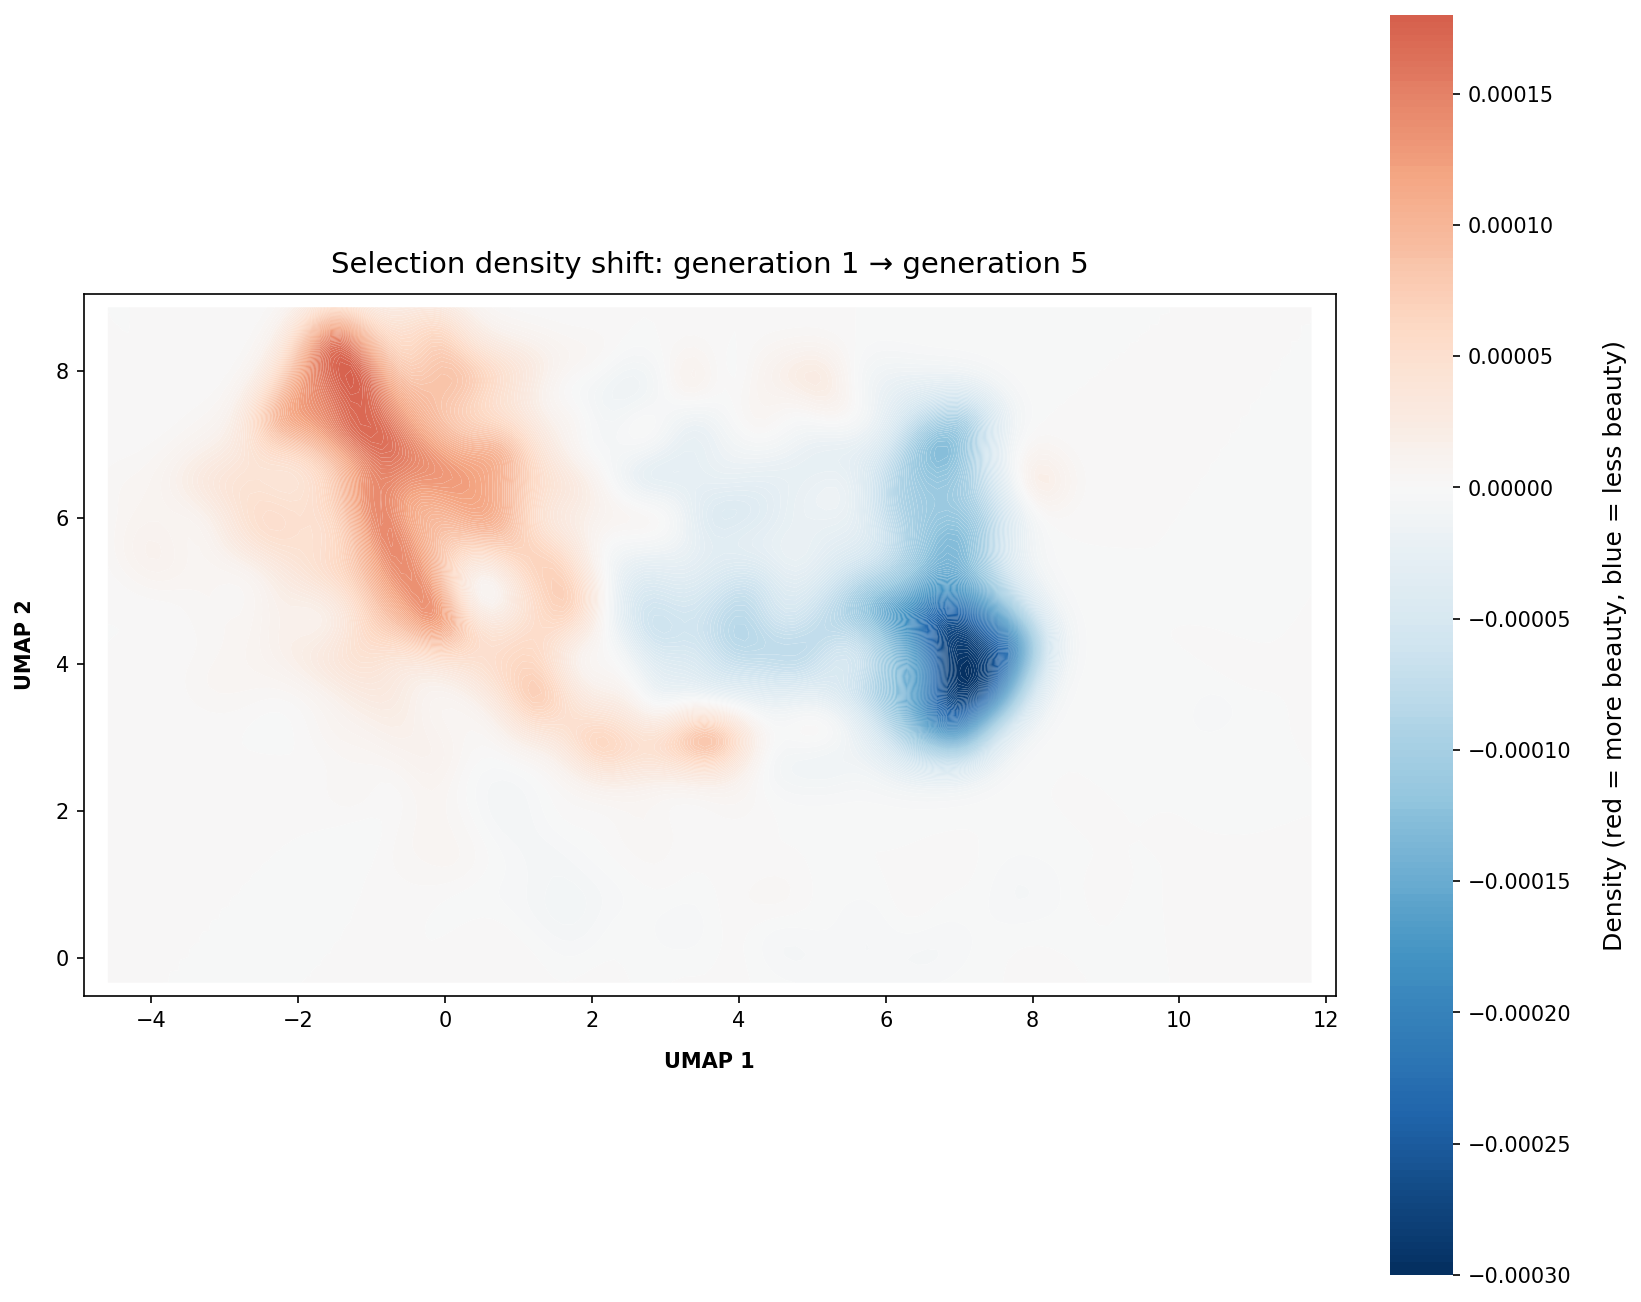

In [10]:
plot_density_diff(
    grid_x, grid_y, density_diff, umap_bounds,
    save_path=os.path.join(FIG_DIR, "gen1_vs_gen5_density_diff.png"),
)